In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
BASE_PATH = '../dataset'
BPS_FOLDER = os.path.join(BASE_PATH, 'dataset_bps')
EDA_OUTPUT_FOLDER = os.path.join(BASE_PATH, 'eda_outputs')

In [4]:
files = [
    f for f in os.listdir(BPS_FOLDER)
    if f.endswith(".csv")
]

print(f"Jumlah file BPS: {len(files)}") 

Jumlah file BPS: 34


In [5]:
all_bps = []

for file in files:
    path = os.path.join(BPS_FOLDER, file)
    df = pd.read_csv(path)
    all_bps.append(df)

bps = pd.concat(all_bps, ignore_index=True)

print(bps.shape)    

(3806, 5)


In [6]:
bps = bps.rename(columns={
    'Kabupaten/Kota': 'kabupaten',
    'Tahun': 'tahun',
    'Luas Panen Tanaman Padi (ha)': 'luas_panen',
    'Produktivitas Tanaman Padi (ku/ha)': 'produktivitas',
    'Rekap Produksi Padi (ton)': 'produksi'
})

# Sekarang kolom Anda sudah berubah menjadi lebih simpel!
print(bps.columns)

Index(['kabupaten', 'luas_panen', 'produktivitas', 'produksi', 'tahun'], dtype='object')


In [7]:
print(bps.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3806 entries, 0 to 3805
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   kabupaten      3806 non-null   object
 1   luas_panen     3806 non-null   object
 2   produktivitas  3806 non-null   object
 3   produksi       3806 non-null   object
 4   tahun          3806 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 148.8+ KB
None


In [8]:
print("="*5+" Cek Kolom yang Kosong "+ "="*5)
print(bps.isnull().sum())

===== Cek Kolom yang Kosong =====
kabupaten        0
luas_panen       0
produktivitas    0
produksi         0
tahun            0
dtype: int64


In [9]:
tabel_kosong = bps[bps['produksi'].isnull()]    

print("Daftar baris yang kosong pada kolom produksi:")  
print(tabel_kosong[['kabupaten', 'tahun', 'produksi']])   

Daftar baris yang kosong pada kolom produksi:
Empty DataFrame
Columns: [kabupaten, tahun, produksi]
Index: []


In [10]:
print("Duplikasi data: ", bps.duplicated().sum())

Duplikasi data:  0


In [11]:
print("="*5+" Cek Rentang Tahun "+ "="*5)
print(sorted(bps["tahun"].unique()))

===== Cek Rentang Tahun =====
[2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [12]:
print("="*5+" Total Kabupaten/Kota "+ "="*5)
print(bps["kabupaten"].nunique())

===== Total Kabupaten/Kota =====
484


In [13]:
print(bps.describe())   

             tahun
count  3806.000000
mean   2021.512349
std       2.287078
min    2018.000000
25%    2020.000000
50%    2022.000000
75%    2024.000000
max    2025.000000


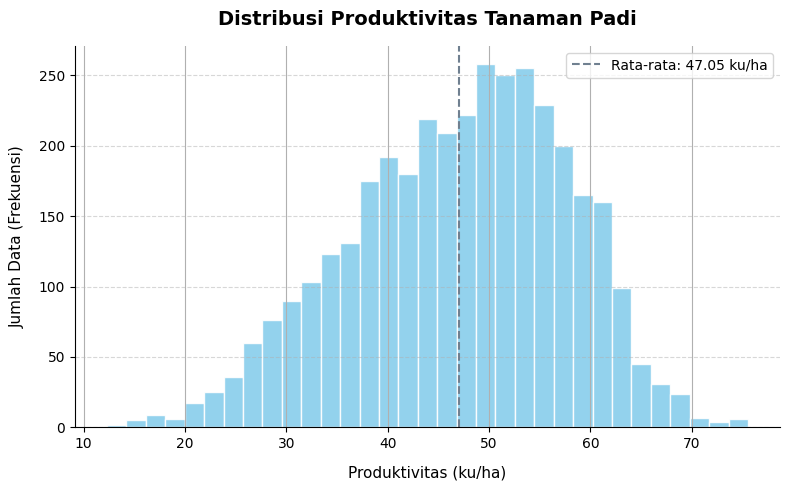

In [ ]:
bps['produktivitas'] = bps['produktivitas'].astype(str).str.strip()
bps['produktivitas'] = bps['produktivitas'].str.replace(' ', '', regex=False)
bps['produktivitas'] = bps['produktivitas'].str.replace(',', '.', regex=False)
bps['produktivitas'] = pd.to_numeric(bps['produktivitas'], errors='coerce')
bps = bps.dropna(subset=['produktivitas'])

rata_rata_produktivitas = bps['produktivitas'].mean()    

plt.figure(figsize=(8, 5))

bps['produktivitas'].hist(
    bins='auto',
    color='skyblue', 
    edgecolor='white', 
    alpha=0.9
)

plt.axvline(
    rata_rata_produktivitas, 
    color='slategray', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Rata-rata: {rata_rata_produktivitas:.2f} ku/ha'
)

plt.legend(loc='upper right', fontsize=10, frameon=True)

plt.title("Distribusi Produktivitas Tanaman Padi", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Produktivitas (ku/ha)", fontsize=11, labelpad=10)
plt.ylabel("Jumlah Data (Frekuensi)", fontsize=11, labelpad=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menghilangkan garis bingkai atas dan kanan
for spine in plt.gca().spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    os.path.join(EDA_OUTPUT_FOLDER, 'bps_produktivitas_hist.png'),
    dpi=300,    
    bbox_inches='tight'
)
plt.show()

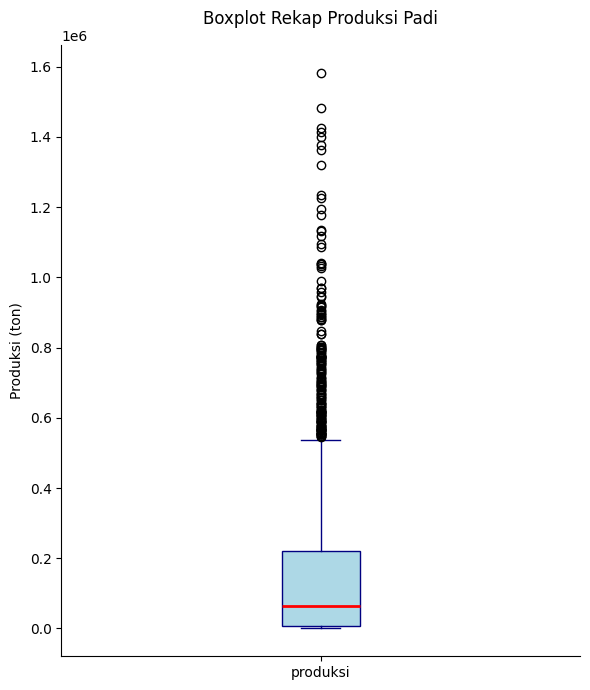

In [ ]:
bps['produksi'] = bps['produksi'].astype(str).str.strip()
bps['produksi'] = bps['produksi'].str.replace(' ', '', regex=False)
bps['produksi'] = bps['produksi'].str.replace(',', '.', regex=False)
bps['produksi'] = pd.to_numeric(bps['produksi'], errors='coerce')

bps = bps[bps['produksi'] > 0] 
bps = bps.dropna(subset=['produksi'])

plt.figure(figsize=(6, 7))

bps.boxplot(
    column="produksi",
    grid=False,            
    patch_artist=True,      
    boxprops=dict(facecolor='lightblue', color='navy'),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    medianprops=dict(color='red', linewidth=2)  
)
    
plt.title("Boxplot Rekap Produksi Padi", fontsize=12, pad=15)
plt.ylabel("Produksi (ton)", fontsize=10)

for spine in plt.gca().spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.tight_layout()
plt.savefig(
    os.path.join(EDA_OUTPUT_FOLDER, 'bps_produksi_boxplot.png'),
    dpi=300, 
    bbox_inches='tight' 
)
plt.show()

In [16]:
bps.head()

,kabupaten,luas_panen,produktivitas,produksi,tahun
0,Kab. Simeulue,"6085,45",33.20,20200.91,2018
1,Kab. Aceh Singkil,"967,02",56.16,5430.41,2018
2,Kab. Aceh Selatan,"9242,78",62.29,57573.07,2018
3,Kab. Aceh Tenggara,"10488,65",65.45,68651.03,2018
4,Kab. Aceh Timur,"30947,54",56.40,174531.52,2018


In [20]:
bps.to_csv(os.path.join(EDA_OUTPUT_FOLDER, 'bps_cleaned.csv'), index=False)